In [1]:
from helper_lib.data_loader import get_data_loader
from helper_lib.trainer import train_vae_model, vae_loss_function
from helper_lib.model import get_model
from helper_lib.generator import generate_samples
from helper_lib.utils import get_device, set_seed

import torch.optim as optim

print("VAE helper functions imported successfully")

VAE helper functions imported successfully


In [2]:
set_seed(42)
device = get_device()
print("Using device:", device)

train_loader = get_data_loader("./data", batch_size=64, train=True, dataset_name="fashionmnist")

vae = get_model("VAE")
optimizer = optim.Adam(vae.parameters(), lr=0.001)

trained_vae = train_vae_model(
    model=vae,
    data_loader=train_loader,
    criterion=vae_loss_function,
    optimizer=optimizer,
    device=device,
    epochs=1
)

Using device: mps


100%|██████████| 26.4M/26.4M [15:07<00:00, 29.1kB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 37.0kB/s]
100%|██████████| 4.42M/4.42M [01:34<00:00, 46.6kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.61MB/s]
Epoch 1/1: 100%|███████████████████████████████████████████████████| 938/938 [00:18<00:00, 52.08it/s, loss=4194034.0000]

Epoch 1: Loss=9411378.6839
Finished Training


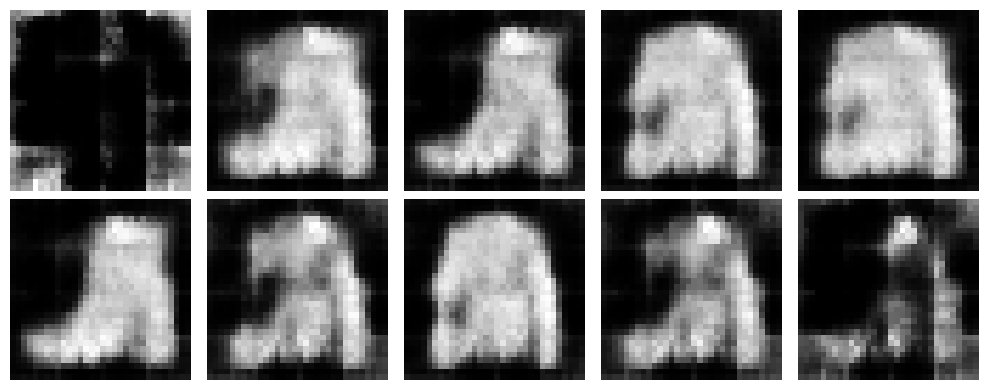

In [3]:
generate_samples(trained_vae, device, num_samples=10)